#### Final Project - Eigen-Value-Decomposition (ICDA 5003 2026 Spring)

#### Envrionment Setup & Data Loading

In [79]:
# Import Library
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt

%matplotlib inline

# Load Data
data = sio.loadmat("Final11Pattern.mat") # Dictionary Type
keys = [k for k in data if not k.startswith("__")] # Get the key, ignoring the hidden variables
print(keys)
Matrix = data.get("Matrix")   # (3, 3, 11)
print(Matrix.shape)

['Matrix']
(3, 3, 11)


#### Create Bit-True Model for EVD by Iterative QR

In [80]:
# Reference Eigen-Value Decomposition
def reference_evd(A):
    return np.linalg.eigh(A)

# Quantization
def quantize(z, b):
    return np.floor(z * 2**b) / 2**b

# CORDIC Scaling Factor
def cordic_scaling_factor(n_stages):
    K = 1.0
    for i in range(n_stages):
        K *= np.sqrt(1.0 + 2.0 ** (-2 * i))
    return K

# Configuration Quantization Setting
class EVDConfig:

    def __init__(
        self,
        b=16,                   # fractional bits for quantize
        n_stages=16,            # CORDIC micro-rotation stages
        mu=0.0,                 # shift parameter
        max_iter=8,             # QR iterations (8 needed for vec RMSE < 1e-2)
    ):
        self.b = b
        self.n_stages = n_stages
        self.mu = mu
        self.max_iter = max_iter

    def q(self, z):
        return quantize(z, self.b)

    def scale_cordic(self, x):
        return self.q(x / cordic_scaling_factor(self.n_stages))


# Fixed-Point Matrix Multiply
def qmatmul(A, B, cfg):
    n = A.shape[0]
    C = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            acc = cfg.q(0.0)
            for k in range(n):
                acc = cfg.q(acc + cfg.q(A[i, k]) * cfg.q(B[k, j]))
            C[i, j] = acc
    return C


# CORDIC Vectoring Mode
def cordic_vectoring(x, y, cfg):
    q = cfg.q
    w_xy = cfg.b
    phase_adjust = 0.0

    if x < 0:
        phase_adjust = np.pi if y >= 0 else -np.pi
        x, y = -x, -y

    xi = int(np.floor(x * 2**w_xy))
    yi = int(np.floor(y * 2**w_xy))
    theta = 0.0

    for i in range(cfg.n_stages):
        mu = -1 if yi > 0 else 1
        elem_angle = q(np.arctan(2.0 ** -i))
        dX = yi >> i
        dY = xi >> i
        xi = xi - mu * dX
        yi = yi + mu * dY
        theta = q(theta - mu * elem_angle)

    k = cordic_scaling_factor(cfg.n_stages)
    x_out = q(xi / (2**w_xy) / k)
    y_out = q(yi / (2**w_xy) / k)
    theta_out = q(theta + phase_adjust)
    return x_out, y_out, theta_out

# CORDIC Rotation Mode: integer-shift HW style matching vectoring
def cordic_rotation(x, y, theta, cfg):
    q = cfg.q
    w_xy = cfg.b
    z = q(theta)

    # Quadrant pre-rotation (mirrors vectoring's x<0 handling)
    if z > q(np.pi / 2):
        x, y = -x, -y
        z = q(z - q(np.pi))
    elif z < -q(np.pi / 2):
        x, y = -x, -y
        z = q(z + q(np.pi))

    xi = int(np.floor(x * 2**w_xy))
    yi = int(np.floor(y * 2**w_xy))

    for i in range(cfg.n_stages):
        elem_angle = q(np.arctan(2.0 ** -i))
        dX = yi >> i
        dY = xi >> i
        if z >= 0:
            xi = xi + dX
            yi = yi - dY
            z = q(z - elem_angle)
        else:
            xi = xi - dX
            yi = yi + dY
            z = q(z + elem_angle)

    k = cordic_scaling_factor(cfg.n_stages)
    x_out = q(xi / (2**w_xy) / k)
    y_out = q(yi / (2**w_xy) / k)
    return x_out, y_out

# Apply Givens Rotation to R
def apply_givens_rows(M, p, q, col, cfg):
    M = np.array(M, dtype=float, copy=True) # make M copy
    # extract the two rows to be rotated and make copies -> quantization
    rp = cfg.q(M[p, :].copy())
    rq = cfg.q(M[q, :].copy())
    # vectoring: zero pivot and obtain theta
    rp[col], rq[col], theta = cordic_vectoring(rp[col], rq[col], cfg)
    # rotation: apply same theta to remaining columns
    for m in range(col + 1, M.shape[1]):
        rp[m], rq[m] = cordic_rotation(rp[m], rq[m], theta, cfg)
    # update the matrix
    M[p, :] = rp
    M[q, :] = rq
    return M, theta

# Apply Givens Rotation to Q
def apply_givens_q(Q, p, q, theta, cfg):
    Q = np.array(Q, dtype=float, copy=True)
    for i in range(Q.shape[0]):
        Q[i, p], Q[i, q] = cordic_rotation(cfg.q(Q[i, p]), cfg.q(Q[i, q]), theta, cfg)
    return Q


# 3 x 3 QR Decomposition
def qr_givens(A, cfg):
    n = A.shape[0] # Get n for I
    R = cfg.q(np.array(A, dtype=float)) # Initialize: R = q(A)
    Q = cfg.q(np.eye(n)) # Initialize: Q = q(I) [n x n]
    # create (row1, row2, col) list
    pairs = [(0, 1, 0), (0, 2, 0), (1, 2, 1)]
    # unpacking from pairs
    for p, q, col in pairs:
        R, theta = apply_givens_rows(R, p, q, col, cfg)
        Q = apply_givens_q(Q, p, q, theta, cfg)
    return cfg.q(Q), cfg.q(R)


# Eigen Value Decomposition by Iterative QR Algorithm
def iterative_qr_evd(A, cfg):
    n = A.shape[0]
    Ak = cfg.q(np.array(A, dtype=float)) # Initialize: Ak = q(A), copy A
    U = cfg.q(np.eye(n)) # Initialize: U = q(I)
    iters = 0
    I = np.eye(n)

    for _ in range(cfg.max_iter): # Run QR iterations
        iters += 1 
        T = cfg.q(Ak - cfg.mu * I) # Initialize: T = q(Ak - mu * I), Now mu = 0
        Q, R = qr_givens(T, cfg) # QR Decomposition
        Ak = cfg.q(qmatmul(R, Q, cfg) + cfg.mu * I) # Update Ak
        U = cfg.q(qmatmul(U, Q, cfg)) # Update U

    lam = np.diag(Ak) # Eigenvalues
    return lam, U, Ak, iters


# 參考 Reference 去修正 Eigenvector 的排序
def align_eigenpairs(lam_ref, V_ref, lam_hat, V_hat):
    idx = np.argsort(lam_hat)
    lam_hat = lam_hat[idx]
    V_hat = V_hat[:, idx]
    for i in range(len(lam_ref)):
        if np.dot(V_ref[:, i], V_hat[:, i]) < 0:
            V_hat[:, i] *= -1
    return lam_hat, V_hat


def rmse_eigenvalues(lam_ref, lam_hat):
    return float(np.sqrt(np.mean((lam_ref - lam_hat) ** 2)))


def rmse_eigenvectors(V_ref, V_hat):
    """Spec: sqrt( (1/9) * sum_i ||v_hat_i - v_i||^2 )."""
    sq = sum(
        np.linalg.norm(V_ref[:, i] - V_hat[:, i]) ** 2
        for i in range(V_ref.shape[1])
    )
    return float(np.sqrt(sq / 9))


def evaluate_evd(A, cfg):
    """Run iterative QR + RMSE against eigh for one matrix."""
    lam_ref, V_ref = reference_evd(A)
    lam_hat, V_hat, _, n_iter = iterative_qr_evd(A, cfg)
    lam_hat, V_hat = align_eigenpairs(lam_ref, V_ref, lam_hat, V_hat)
    return {
        "rmse_lam": rmse_eigenvalues(lam_ref, lam_hat),
        "rmse_vec": rmse_eigenvectors(V_ref, V_hat),
        "n_iter": n_iter,
        "lam_ref": lam_ref,
        "lam_hat": lam_hat,
    }


def evaluate_all_patterns(Matrix, cfg):
    """Evaluate all 11 test matrices; return per-set RMSE arrays."""
    n_sets = Matrix.shape[2]
    rmse_lam = np.zeros(n_sets)
    rmse_vec = np.zeros(n_sets)
    for s in range(n_sets):
        r = evaluate_evd(Matrix[:, :, s], cfg)
        rmse_lam[s] = r["rmse_lam"]
        rmse_vec[s] = r["rmse_vec"]
    return rmse_lam, rmse_vec


def make_fixed_cfg(b=16, n_stages=20, **kwargs):
    """Helper: bit-true fixed-point + CORDIC Givens parameters."""
    defaults = dict(max_iter=8)
    defaults.update(kwargs)
    return EVDConfig(b=b, n_stages=n_stages, **defaults)

In [81]:
# --- Q1 validation (bit-true fixed-point + CORDIC) ---
cfg_q1 = make_fixed_cfg(b=16, n_stages=20)
rmse_lam, rmse_vec = evaluate_all_patterns(Matrix, cfg_q1)
print("Q1 cfg: b=16, stages=20, max_iter=8")
print("max RMSE lam/vec:", rmse_lam.max(), rmse_vec.max())
print("λ pass 1e-2:", (rmse_lam < 1e-2).all())
print("v pass 1e-2:", (rmse_vec < 1e-2).all())
print("CORDIC K =", cordic_scaling_factor(cfg_q1.n_stages))

Q1 cfg: b=16, stages=20, max_iter=8
max RMSE lam/vec: 0.0016525537830038527 0.004002604763532497
λ pass 1e-2: True
v pass 1e-2: True
CORDIC K = 1.646760258120067


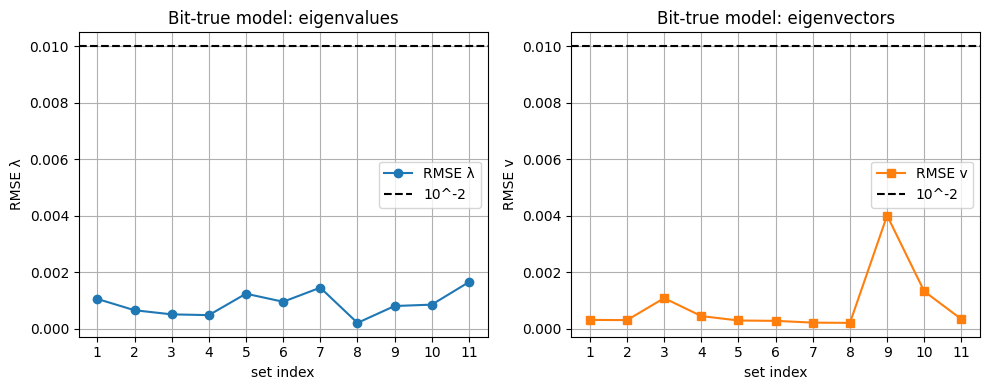

λ fail (>=0.01): 0/11
v fail (>=0.01): 0/11


In [82]:
# --- Q2: bit-true model RMSE vs set index (1~11) ---
RMSE_THRESH = 1e-2
sets = np.arange(1, Matrix.shape[2] + 1)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(sets, rmse_lam, "o-", label="RMSE λ")
axes[0].axhline(RMSE_THRESH, color="k", ls="--", label="10^-2")
axes[0].set_xlabel("set index")
axes[0].set_ylabel("RMSE λ")
axes[0].set_title("Bit-true model: eigenvalues")
axes[0].set_xticks(sets)
axes[0].legend()
axes[0].grid(True)

axes[1].plot(sets, rmse_vec, "s-", color="C1", label="RMSE v")
axes[1].axhline(RMSE_THRESH, color="k", ls="--", label="10^-2")
axes[1].set_xlabel("set index")
axes[1].set_ylabel("RMSE v")
axes[1].set_title("Bit-true model: eigenvectors")
axes[1].set_xticks(sets)
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

n_fail_lam = int((rmse_lam >= RMSE_THRESH).sum())
n_fail_vec = int((rmse_vec >= RMSE_THRESH).sum())
print(f"λ fail (>={RMSE_THRESH}): {n_fail_lam}/11")
print(f"v fail (>={RMSE_THRESH}): {n_fail_vec}/11")

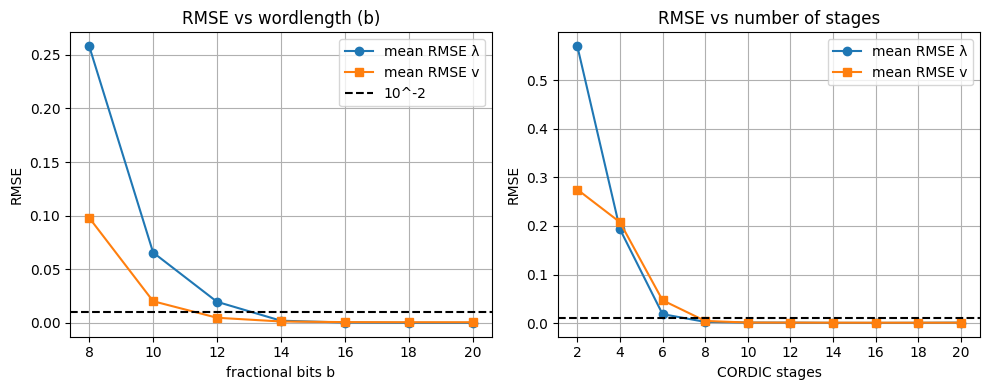

In [83]:
# --- Q1 sweeps: RMSE vs wordlength (b) and vs CORDIC stages ---

def sweep_wordlength(Matrix, b_list, n_stages=16):
    """RMSE vs fractional bits b (mean over 11 patterns)."""
    mean_lam, mean_vec, max_lam, max_vec = [], [], [], []
    for b in b_list:
        cfg = make_fixed_cfg(b=b, n_stages=n_stages)
        rl, rv = evaluate_all_patterns(Matrix, cfg)
        mean_lam.append(rl.mean())
        mean_vec.append(rv.mean())
        max_lam.append(rl.max())
        max_vec.append(rv.max())
    return np.array(mean_lam), np.array(mean_vec), np.array(max_lam), np.array(max_vec)


def sweep_stages(Matrix, stage_list, b=16):
    """RMSE vs CORDIC micro-rotation stages."""
    mean_lam, mean_vec, max_lam, max_vec = [], [], [], []
    for n in stage_list:
        cfg = make_fixed_cfg(b=b, n_stages=n)
        rl, rv = evaluate_all_patterns(Matrix, cfg)
        mean_lam.append(rl.mean())
        mean_vec.append(rv.mean())
        max_lam.append(rl.max())
        max_vec.append(rv.max())
    return np.array(mean_lam), np.array(mean_vec), np.array(max_lam), np.array(max_vec)


# Example sweeps (adjust ranges as needed)
B_LIST = [8, 10, 12, 14, 16, 18, 20]
STAGE_LIST = [2, 4, 6, 8, 10, 12, 14, 16, 18, 20]

ml, mv, xl, xv = sweep_wordlength(Matrix, B_LIST, n_stages=16)
sl, sv, _, _ = sweep_stages(Matrix, STAGE_LIST, b=16)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(B_LIST, ml, "o-", label="mean RMSE λ")
axes[0].plot(B_LIST, mv, "s-", label="mean RMSE v")
axes[0].axhline(1e-2, color="k", ls="--", label="10^-2")
axes[0].set_xlabel("fractional bits b")
axes[0].set_ylabel("RMSE")
axes[0].set_title("RMSE vs wordlength (b)")
axes[0].set_xticks(B_LIST)
axes[0].legend()
axes[0].grid(True)

axes[1].plot(STAGE_LIST, sl, "o-", label="mean RMSE λ")
axes[1].plot(STAGE_LIST, sv, "s-", label="mean RMSE v")
axes[1].axhline(1e-2, color="k", ls="--")
axes[1].set_xlabel("CORDIC stages")
axes[1].set_ylabel("RMSE")
axes[1].set_title("RMSE vs number of stages")
axes[1].set_xticks(STAGE_LIST)  # integer stages only (avoid 2.5, 5.0 auto ticks)
axes[1].legend()
axes[1].grid(True)
plt.tight_layout()
plt.show()

2D sweep: this may take a few minutes...


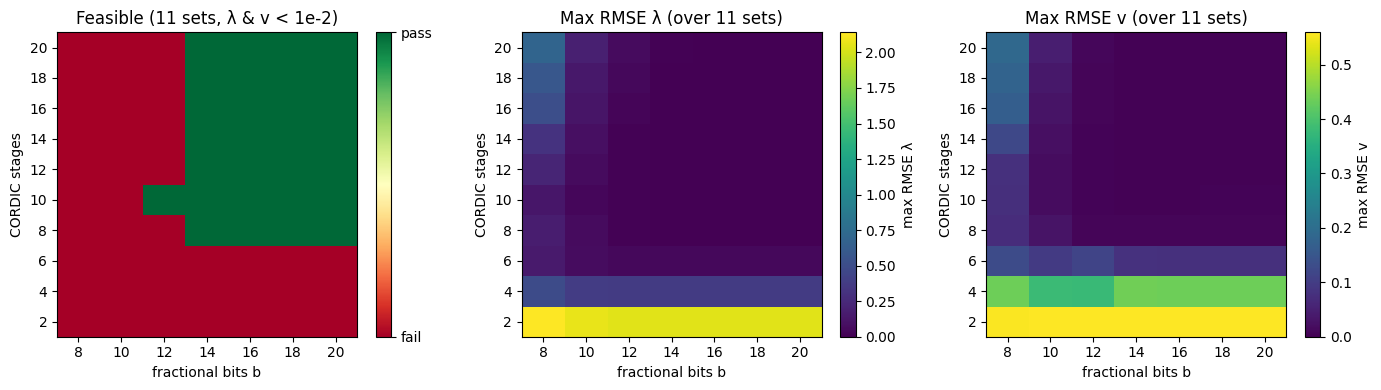

Feasible cells: 29 / 70 (b × stages grid)


In [84]:
# --- 2D sweep: (b, n_stages) feasibility for min-parameter search ---
RMSE_THRESH = 1e-2

def sweep_grid(Matrix, b_list, stage_list, max_iter=8):
    """
    For each (b, n_stages): max RMSE over 11 sets and pass flag (lam & vec < thresh).
    Returns 2D arrays indexed as [stage_idx, b_idx] for imshow(origin='lower').
    """
    nb, ns = len(b_list), len(stage_list)
    max_lam = np.zeros((ns, nb))
    max_vec = np.zeros((ns, nb))
    pass_all = np.zeros((ns, nb), dtype=bool)

    for i, n in enumerate(stage_list):
        for j, b in enumerate(b_list):
            cfg = make_fixed_cfg(b=b, n_stages=n, max_iter=max_iter)
            rl, rv = evaluate_all_patterns(Matrix, cfg)
            max_lam[i, j] = rl.max()
            max_vec[i, j] = rv.max()
            pass_all[i, j] = (rl < RMSE_THRESH).all() and (rv < RMSE_THRESH).all()
    return max_lam, max_vec, pass_all


B_GRID = [8, 10, 12, 14, 16, 18, 20]
STAGE_GRID = [2, 4, 6, 8, 10, 12, 14, 16, 18, 20]

print("2D sweep: this may take a few minutes...")
max_lam_2d, max_vec_2d, pass_2d = sweep_grid(Matrix, B_GRID, STAGE_GRID, max_iter=8)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Pass / fail (11/11 sets, both lambda and vector)
im0 = axes[0].imshow(
    pass_2d.astype(float),
    origin="lower",
    aspect="auto",
    cmap=plt.cm.RdYlGn,
    vmin=0,
    vmax=1,
)
axes[0].set_xticks(range(len(B_GRID)), B_GRID)
axes[0].set_yticks(range(len(STAGE_GRID)), STAGE_GRID)
axes[0].set_xlabel("fractional bits b")
axes[0].set_ylabel("CORDIC stages")
axes[0].set_title("Feasible (11 sets, λ & v < 1e-2)")
cb0 = fig.colorbar(im0, ax=axes[0], ticks=[0, 1])
cb0.ax.set_yticklabels(["fail", "pass"])

# Max RMSE lambda
im1 = axes[1].imshow(
    max_lam_2d,
    origin="lower",
    aspect="auto",
    cmap="viridis",
    vmin=0,
    vmax=max(0.15, max_lam_2d.max()),
)
axes[1].set_xticks(range(len(B_GRID)), B_GRID)
axes[1].set_yticks(range(len(STAGE_GRID)), STAGE_GRID)
axes[1].set_xlabel("fractional bits b")
axes[1].set_ylabel("CORDIC stages")
axes[1].set_title("Max RMSE λ (over 11 sets)")
fig.colorbar(im1, ax=axes[1], label="max RMSE λ")

# Max RMSE vector
im2 = axes[2].imshow(
    max_vec_2d,
    origin="lower",
    aspect="auto",
    cmap="viridis",
    vmin=0,
    vmax=max(0.15, max_vec_2d.max()),
)
axes[2].set_xticks(range(len(B_GRID)), B_GRID)
axes[2].set_yticks(range(len(STAGE_GRID)), STAGE_GRID)
axes[2].set_xlabel("fractional bits b")
axes[2].set_ylabel("CORDIC stages")
axes[2].set_title("Max RMSE v (over 11 sets)")
fig.colorbar(im2, ax=axes[2], label="max RMSE v")

plt.tight_layout()
plt.show()

n_pass = int(pass_2d.sum())
print(f"Feasible cells: {n_pass} / {pass_2d.size} (b × stages grid)")